# Notebook 2 — ME/CFS Metabolite Interpretation / Downstream Analysis

Cleaned version. This notebook **does not fit or export new coefficients for the locked 10-metabolite panel**. Any 10-metabolite coefficients/intercept should come only from Notebook 1.

Notebook 2 is for interpretation/downstream work: loading the locked panel, loading Notebook 1 scores/artifacts, plotting score distributions, checking metadata relationships, multi-omics exploratory comparisons, robustness checks, and final exports.

In [6]:
# =========================
# 0. Imports + paths
# =========================

import os
import re
import itertools
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from scipy.special import expit

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

BASE = "../.."

META_PATH = f"{BASE}/data/metadata/Metadata_061523.csv"
METAB_PATH = f"{BASE}/data/metabolomics/Metabolomics_maaslined_norun.csv"

QUEST_PATH = f"{BASE}/data/quest_lab/Quest_lab_maaslined.csv"

IMMUNE_PCT_PATH = f"{BASE}/data/immuno/Immune_percentage.csv"
IMMUNE_RES_PATH = f"{BASE}/data/immuno/Immune_residue.csv"

KEGG_PATH = f"{BASE}/data/metagenomics/KEGG_maaslined.csv"
SPECIES_PATH = f"{BASE}/data/metagenomics/Specie_abundance_maaslined.csv"

OUT_DIR = Path(f"{BASE}/output/locked_panel_biology")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DIR = Path(f"{BASE}/output/FINAL_MECFS_SIGNATURE_EXPORT")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Current folder:", Path.cwd())
print("Metadata exists:", Path(META_PATH).exists())
print("Metabolomics exists:", Path(METAB_PATH).exists())

Current folder: c:\Users\rohan\OneDrive\Desktop\ME-CFS\src\main
Metadata exists: True
Metabolomics exists: True


In [7]:
# =========================
# 1. Locked 10-metabolite panel from Notebook 1
# =========================
# Important: do NOT compute the 10-panel coefficients in this notebook.
# The panel itself is okay to define here, but coefficients/intercept must come from Notebook 1.

LOCKED_PANEL = [
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)",
    "N-acetylglutamate",
    "N4-acetylcytidine",
    "sphingomyelin (d18:1/24:1, d18:2/24:0)*",
    "1-methylurate",
    "N-palmitoyl-sphingosine (d18:1/16:0)",
    "3-(4-hydroxyphenyl)lactate",
    "N-acetylglucosamine/N-acetylgalactosamine",
    "vanillylmandelate (VMA)",
    "4-vinylguaiacol sulfate"
]

len(LOCKED_PANEL)


10

In [8]:
# =========================
# 2. Load baseline tp1 metabolomics + labels
# =========================

meta_raw = pd.read_csv(META_PATH)
metab_raw = pd.read_csv(METAB_PATH)

metab = (
    metab_raw
    .set_index("Unnamed: 0")
    .T
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

metab["participant_id"] = (
    metab["sample_id"]
    .str.replace(r"_tp\d+$", "", regex=True)
)

metab["timepoint"] = (
    metab["sample_id"]
    .str.extract(r"_tp(\d+)")
)

tp1 = metab[metab["timepoint"] == "1"].copy()

meta_raw["participant_id"] = meta_raw["samples_id"].astype(str)
meta_tp1 = meta_raw[meta_raw["timepoints"] == "tp1"].copy()

df = tp1.merge(
    meta_tp1,
    on="participant_id",
    how="inner"
)

y = (
    df["study_ptorhc"]
    .map({"MECFS": 1, "Control": 0})
    .astype(int)
)

X_panel = df[LOCKED_PANEL].apply(
    pd.to_numeric,
    errors="coerce"
)

print("Panel data:", X_panel.shape)
print("Class counts:", y.value_counts().to_dict())
print("Missing:", X_panel.isna().sum().sum())

Panel data: (214, 10)
Class counts: {1: 135, 0: 79}
Missing: 0


In [9]:
# =========================
# 3. Load Notebook 1 score file
# =========================
# This keeps Notebook 2 from refitting the 10-metabolite model.
# Update this path to wherever Notebook 1 exported the subject-level scores.

NB1_SCORE_CANDIDATES = [
    Path(f"{BASE}/output/mecfs_metabolite_scores.csv"),
    Path(f"{BASE}/output/locked_panel_biology/mecfs_metabolite_scores.csv"),
    Path(f"{BASE}/output/FINAL_MECFS_SIGNATURE_EXPORT/03_subject_scores_10metab_15multiomics.csv"),
    Path(f"{BASE}/output/FINAL_MECFS_SIGNATURE_EXPORT/03_subject_scores.csv"),
]

score_path = f"{BASE}/src/MECFS_FINAL_SIGNATURES/NB2_MULTIOMICS_INTERPRETATION/04_subject_scores.csv"

if score_path is None:
    raise FileNotFoundError(
        "Could not find Notebook 1 score file. Export subject-level 10-metabolite scores from Notebook 1 first. "
        "Do not refit the 10-metabolite coefficient model in Notebook 2."
    )

score_df = pd.read_csv(score_path)

# Normalize expected column names if needed.
if "score" in score_df.columns and "mecfs_score" not in score_df.columns:
    score_df = score_df.rename(columns={"score": "mecfs_score"})

required_score_cols = {"participant_id", "mecfs_score"}
missing = required_score_cols - set(score_df.columns)
if missing:
    raise ValueError(f"Score file is missing required columns: {missing}")

if "label" not in score_df.columns:
    score_df = score_df.merge(
        df[["participant_id"]].assign(label=y.values),
        on="participant_id",
        how="left"
    )

print("Loaded scores from:", score_path)
print(score_df.shape)
display(score_df.head())


Loaded scores from: ../../src/MECFS_FINAL_SIGNATURES/NB2_MULTIOMICS_INTERPRETATION/04_subject_scores.csv
(249, 5)


,participant_id,label,mecfs_score,multiomics_score,delta
0,SAM000269,1.0,0.636568,0.736132,0.099564
1,SAM000268,1.0,0.740155,0.427131,-0.313025
2,SAM000266,1.0,0.516147,0.303384,-0.212762
3,SAM000257,0.0,0.100672,0.036903,-0.063769
4,SAM000260,1.0,0.868054,0.837209,-0.030846


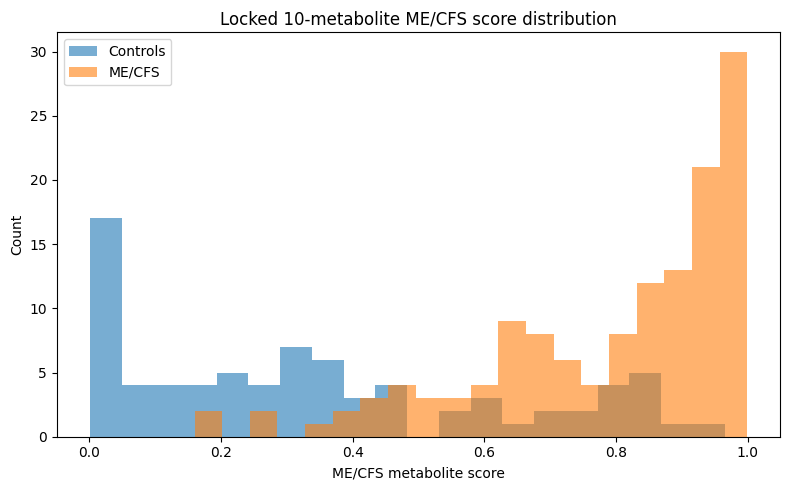

In [10]:
# =========================
# 4. Score distribution plot
# =========================

plt.figure(figsize=(8, 5))

plt.hist(
    score_df.loc[score_df["label"] == 0, "mecfs_score"],
    bins=20,
    alpha=0.6,
    label="Controls"
)

plt.hist(
    score_df.loc[score_df["label"] == 1, "mecfs_score"],
    bins=20,
    alpha=0.6,
    label="ME/CFS"
)

plt.xlabel("ME/CFS metabolite score")
plt.ylabel("Count")
plt.title("Locked 10-metabolite ME/CFS score distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "mecfs_score_distribution.png", dpi=300)
plt.show()


In [11]:
# =========================
# 5. Merge score with metadata
# =========================

score_meta = score_df.merge(
    meta_raw,
    left_on="participant_id",
    right_on="samples_id",
    how="left"
)

print(score_meta.shape)
display(score_meta.head())


(249, 28)


,participant_id_x,label,mecfs_score,multiomics_score,delta,Unnamed: 0,sample_id_tp1,samples_id,timepoints,study_ptorhc,...,diet_sugar,diet_veg,diet_grains,diet_fruit,antifungals,antibiotics,probiotics,antivirals,IBS,participant_id_y
0,SAM000269,1.0,0.636568,0.736132,0.099564,SAM000269_tp1,SAM000269,SAM000269,tp1,MECFS,...,4.0,2.0,4.0,3.0,No,No,No,No,2.0,SAM000269
1,SAM000268,1.0,0.740155,0.427131,-0.313025,SAM000268_tp1,SAM000268,SAM000268,tp1,MECFS,...,2.0,3.0,4.0,4.0,No,No,No,No,1.0,SAM000268
2,SAM000266,1.0,0.516147,0.303384,-0.212762,SAM000266_tp1,SAM000266,SAM000266,tp1,MECFS,...,4.0,2.0,1.0,2.0,No,No,No,No,3.0,SAM000266
3,SAM000257,0.0,0.100672,0.036903,-0.063769,SAM000257_tp1,SAM000257,SAM000257,tp1,Control,...,4.0,3.0,2.0,4.0,No,No,No,No,NaN,SAM000257
4,SAM000260,1.0,0.868054,0.837209,-0.030846,SAM000260_tp1,SAM000260,SAM000260,tp1,MECFS,...,3.0,4.0,1.0,3.0,No,No,No,No,3.0,SAM000260


In [12]:
# =========================
# 6. Correlate numeric metadata with Notebook 1 metabolite score
# =========================

numeric_cols = score_meta.select_dtypes(include="number").columns.tolist()
rows = []

for c in numeric_cols:
    if c in ["label", "mecfs_score"]:
        continue

    temp = score_meta[["mecfs_score", c]].dropna()

    if len(temp) > 20:
        rows.append({
            "variable": c,
            "spearman_corr_with_score": temp["mecfs_score"].corr(temp[c], method="spearman"),
            "n": len(temp)
        })

corr_df = (
    pd.DataFrame(rows)
    .sort_values("spearman_corr_with_score", key=abs, ascending=False)
)

display(corr_df.head(30))


,variable,spearman_corr_with_score,n
0,multiomics_score,0.842943,214
2,age,0.142699,214
3,bmi,0.111726,177
7,diet_grains,-0.107235,211
1,delta,0.101070,214
9,IBS,0.089789,134
6,diet_veg,-0.089506,211
8,diet_fruit,0.078242,211
4,diet_meat,0.026525,211
5,diet_sugar,0.001617,211


In [13]:
# =========================
# 9. Helper functions for multi-omics loading
# =========================

def strip_tp(x):
    return re.sub(r"_tp\d+$", "", str(x))

def get_tp(x):
    m = re.search(r"_tp(\d+)$", str(x))
    return m.group(1) if m else np.nan

def load_transposed_omics(path, prefix, min_complete=0.80):
    raw = pd.read_csv(path)
    feature_col = raw.columns[0]

    mat = (
        raw
        .set_index(feature_col)
        .T
        .reset_index()
        .rename(columns={"index": "sample_id"})
    )

    mat["participant_id"] = mat["sample_id"].apply(strip_tp)
    mat["tp"] = mat["sample_id"].apply(get_tp)

    if mat["tp"].notna().any():
        mat = mat[mat["tp"] == "1"].copy()

    mat = mat.drop(columns=["sample_id", "tp"], errors="ignore")
    mat = mat.set_index("participant_id")
    mat = mat.apply(pd.to_numeric, errors="coerce")
    mat = mat.loc[:, mat.notna().mean() > min_complete]
    mat.columns = [f"{prefix}__{c}" for c in mat.columns]

    return mat


In [ ]:
# =========================
# 10. Build multi-omics modalities
# =========================

label_df = meta_tp1[["participant_id", "study_ptorhc"]].drop_duplicates()
label_df["y"] = label_df["study_ptorhc"].map({"MECFS": 1, "Control": 0})
label_df = label_df.dropna(subset=["y"]).copy()
label_df["y"] = label_df["y"].astype(int)
label_df = label_df.set_index("participant_id")

modalities = {}

# Locked metabolite panel only. The features are used as predictors, but the 10-panel coefficients still come from Notebook 1.
metab_all = load_transposed_omics(METAB_PATH, "metab")
modalities["metabaolites"] = metab_all.copy()

# Metadata covariates
meta_cov = meta_tp1.set_index("participant_id")[["age", "bmi", "gender"]].copy()
meta_cov = pd.get_dummies(meta_cov, columns=["gender"], drop_first=True)
modalities["metadata"] = meta_cov.apply(pd.to_numeric, errors="coerce")

# QUEST
if Path(QUEST_PATH).exists():
    modalities["quest"] = load_transposed_omics(QUEST_PATH, "quest")

# Immune
if Path(IMMUNE_PCT_PATH).exists():
    modalities["immune_percentage"] = load_transposed_omics(IMMUNE_PCT_PATH, "immune_pct")

if Path(IMMUNE_RES_PATH).exists():
    modalities["immune_residue"] = load_transposed_omics(IMMUNE_RES_PATH, "immune_res")

# Microbiome / metagenomics
if Path(KEGG_PATH).exists():
    modalities["kegg"] = load_transposed_omics(KEGG_PATH, "kegg")

if Path(SPECIES_PATH).exists():
    modalities["species"] = load_transposed_omics(SPECIES_PATH, "species")

print("Loaded modalities:")
for name, Xmod in modalities.items():
    print(name, Xmod.shape)


Loaded modalities:
metabaolites (215, 876)
metadata (249, 3)
quest (242, 37)
immune_percentage (239, 311)
immune_residue (239, 311)
kegg (238, 4429)
species (238, 118)


In [19]:
# =========================
# 12. Build one multi-omics matrix
# =========================
# Adjust this list if you decide to exclude a modality.

all_modalities = pd.concat([
    modalities[name]
    for name in [
        "metabaolites",
        "quest",
        "immune_residue",
        "species",
        "metadata",
        "kegg"
    ]
    if name in modalities
], axis=1)

multi_df = all_modalities.join(label_df["y"], how="inner")

X_multi = multi_df.drop(columns=["y"])
y_multi = multi_df["y"].astype(int)

print("X_multi:", X_multi.shape)
print("y_multi:", y_multi.value_counts().to_dict())
X_multi.head()


X_multi: (249, 5774)
y_multi: {1: 153, 0: 96}


,metab__S-1-pyrroline-5-carboxylate,metab__1-methylnicotinamide,metab__alpha-ketoglutarate,metab__3-hydroxyisobutyrate,metab__3-hydroxy-3-methylglutarate,metab__cholate,metab__4-hydroxyphenylacetate,"metab__5,6-dihydrothymine","metab__9,10-DiHOME",metab__linoleate (18:2n6),...,kegg__K23508,kegg__K23509,kegg__K23518,kegg__K23535,kegg__K23536,kegg__K23537,kegg__K23541,kegg__K23546,kegg__K23547,kegg__K23573
participant_id,,,,,,,,,,,,,,,,,,,,,
SAM000269,1.476325,0.387559,0.342713,0.488864,0.907234,0.341328,0.139780,0.805863,0.129607,0.918709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAM000268,1.411830,1.383625,0.350704,0.187794,1.005262,0.830513,0.945841,1.184571,0.122377,0.685851,...,87.290443,1.983874,504.895857,2.975811,0.000000,126.967917,3.967747,0.000000,0.000000,6.943558
SAM000266,0.566404,0.840769,0.464346,1.405387,1.436603,1.130044,1.838309,1.333872,0.592418,1.293946,...,176.380662,94.489640,404.415660,0.000000,0.000000,56.693784,5.039447,2.519724,0.000000,7.559171
SAM000257,1.481165,0.846519,0.483156,0.437858,1.052833,0.362826,0.139780,1.732946,0.493230,0.463149,...,36.898544,0.000000,427.408129,6.149757,6.149757,49.198058,6.149757,0.000000,0.000000,12.299515
SAM000260,0.496603,0.478453,0.431380,1.225215,0.852716,0.378776,0.545194,1.669577,0.573258,1.210857,...,114.487336,14.310917,479.415720,1.192576,1.192576,32.199563,3.577729,8.348035,1.192576,1.192576


In [22]:
# =========================
# 13. Multi-omics stability selection with LASSO
# =========================

C_GRID = [0.01, 0.03, 0.06, 0.1, 0.3]
N_REPEATS = 20

selection_counts = Counter()


def clean_feature_name(feature):
    # Preserve modality prefix for multi-omics features.
    return feature

X_train, X_test, y_train, y_test = train_test_split(
            X_multi,
            y_multi,
            test_size=0.20,
            stratify=y_multi,
            random_state=42
    )

for repeat in range(N_REPEATS):
    repeated_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + repeat)
    
    

    for train_idx, _ in repeated_cv.split(X_train, y_train):
        X_fold = X_train.iloc[train_idx]
        y_fold = y_train.iloc[train_idx]

        for C in C_GRID:
            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("lasso", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=5000,
                    random_state=RANDOM_STATE
                ))
            ])

            model.fit(X_fold, y_fold)
            coef = model.named_steps["lasso"].coef_[0]
            selected = X_multi.columns[coef != 0]
            selection_counts.update(selected)

multi_stability = pd.DataFrame({
    "feature": selection_counts.keys(),
    "count": selection_counts.values()
})

multi_stability["frequency"] = multi_stability["count"] / (N_REPEATS * 5 * len(C_GRID))
multi_stability = multi_stability.sort_values("frequency", ascending=False)

display(multi_stability.head(50))
multi_stability.to_csv(OUT_DIR / "multiomics_stability_selection.csv", index=False)


,feature,count,frequency
25,quest__Vitamin B12,297,0.594
8,kegg__K02121,285,0.570
15,metab__3-(4-hydroxyphenyl)lactate,239,0.478
5,metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/...,235,0.470
17,metab__N4-acetylcytidine,232,0.464
7,species__GGB1266_SGB1699,219,0.438
0,metab__N-palmitoyl-sphingosine (d18:1/16:0),218,0.436
1,metab__N-acetylglutamate,211,0.422
2,metab__1-methylurate,186,0.372
18,metab__N-acetylglucosamine/N-acetylgalactosamine,169,0.338


In [24]:
# =========================
# 14. Evaluate multi-omics panel sizes
# =========================

panel_sizes = [5, 10, 15, 20, 30]
rows = []

for k in panel_sizes:
    panel = multi_stability.head(k)["feature"].tolist()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    aucs = cross_val_score(
        model,
        X_train[panel],
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc"
    )

    rows.append({
        "panel_size": k,
        "mean_auc": aucs.mean(),
        "std_auc": aucs.std(),
        "features": panel
    })

panel_results_df = pd.DataFrame(rows)
display(panel_results_df)
panel_results_df.to_csv(OUT_DIR / "multiomics_panel_size_cv.csv", index=False)


,panel_size,mean_auc,std_auc,features
0,5,0.856794,0.066405,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
1,10,0.906244,0.040949,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
2,15,0.929323,0.048157,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
3,20,0.921135,0.039880,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
4,30,0.947823,0.021890,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."


In [26]:
# =========================
# 15. Lock final multi-omics panel
# =========================
# Edit this number if the panel-size analysis suggests a different cutoff.

MULTIOMICS_PANEL_SIZE = 15
MULTIOMICS_PANEL = multi_stability.head(MULTIOMICS_PANEL_SIZE)["feature"].tolist()

print("Locked multi-omics panel size:", len(MULTIOMICS_PANEL))
for f in MULTIOMICS_PANEL:
    print("-", f)


Locked multi-omics panel size: 15
- quest__Vitamin B12
- kegg__K02121
- metab__3-(4-hydroxyphenyl)lactate
- metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- metab__N4-acetylcytidine
- species__GGB1266_SGB1699
- metab__N-palmitoyl-sphingosine (d18:1/16:0)
- metab__N-acetylglutamate
- metab__1-methylurate
- metab__N-acetylglucosamine/N-acetylgalactosamine
- immune_res__% CD8+ M CCR6+ CXCR3- d0
- metab__1-stearoyl-2-oleoyl-GPC (18:0/18:1)
- metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*
- metab__vanillylmandelate (VMA)
- species__Dysosmobacter_welbionis


In [37]:
# =========================
# 16. Final multi-omics score model + coefficients
# =========================
# These coefficients are for the multi-omics model only.
# Do not treat these as the locked 10-metabolite coefficients.

final_multi_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

final_multi_model.fit(X_train[MULTIOMICS_PANEL], y_train)

test_probs = final_multi_model.predict_proba(X_test[MULTIOMICS_PANEL])[:, 1]

test_score_df = pd.DataFrame({
    "participant_id": X_test.index,
    "label": y_test.values,
    "multiomics_score": multi_probs
})

test_coef = pd.Series(
    final_multi_model.named_steps["logreg"].coef_[0],
    index=MULTIOMICS_PANEL,
    name="coefficient"
).sort_values(key=abs, ascending=False)

print("test multi-omics AUC:", roc_auc_score(y_test, test_probs))
display(test_score_df.head())
display(test_coef.reset_index().rename(columns={"index": "feature"}))


# -------------------------------
multi_probs = final_multi_model.predict_proba(X_multi[MULTIOMICS_PANEL])[:, 1]

multi_score_df = pd.DataFrame({
    "participant_id": X_multi.index,
    "label": y_multi.values,
    "multiomics_score": multi_probs
})

multi_coef = pd.Series(
    final_multi_model.named_steps["logreg"].coef_[0],
    index=MULTIOMICS_PANEL,
    name="coefficient"
).sort_values(key=abs, ascending=False)

print("full multi-omics AUC:", roc_auc_score(y_multi, multi_probs))
display(multi_score_df.head())
display(multi_coef.reset_index().rename(columns={"index": "feature"}))


test multi-omics AUC: 0.8200339558573854


,participant_id,label,multiomics_score
0,SAM000490,0,0.298505
1,SAM000279,1,0.960135
2,SAM000326,0,0.911182
3,SAM000276,1,0.290944
4,SAM000467,0,0.003273


,feature,coefficient
0,metab__N-acetylglutamate,1.040520
1,metab__vanillylmandelate (VMA),-0.999361
2,kegg__K02121,0.983886
3,metab__N4-acetylcytidine,0.960111
4,quest__Vitamin B12,0.865884
5,metab__3-(4-hydroxyphenyl)lactate,-0.680154
6,metab__1-methylurate,-0.635737
7,immune_res__% CD8+ M CCR6+ CXCR3- d0,0.614209
8,species__GGB1266_SGB1699,-0.614199
9,metab__N-palmitoyl-sphingosine (d18:1/16:0),0.572794


full multi-omics AUC: 0.9254493464052287


,participant_id,label,multiomics_score
0,SAM000269,1,0.530959
1,SAM000268,1,0.566659
2,SAM000266,1,0.208924
3,SAM000257,0,0.020655
4,SAM000260,1,0.761518


,feature,coefficient
0,metab__N-acetylglutamate,1.040520
1,metab__vanillylmandelate (VMA),-0.999361
2,kegg__K02121,0.983886
3,metab__N4-acetylcytidine,0.960111
4,quest__Vitamin B12,0.865884
5,metab__3-(4-hydroxyphenyl)lactate,-0.680154
6,metab__1-methylurate,-0.635737
7,immune_res__% CD8+ M CCR6+ CXCR3- d0,0.614209
8,species__GGB1266_SGB1699,-0.614199
9,metab__N-palmitoyl-sphingosine (d18:1/16:0),0.572794


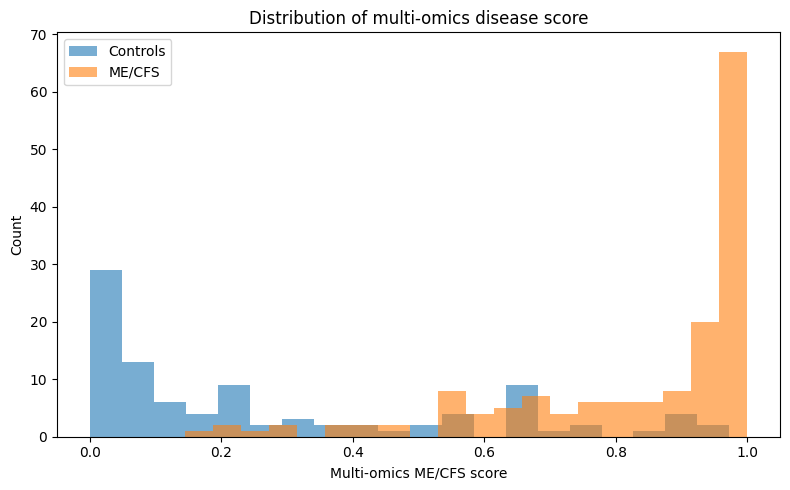

Mann-Whitney p = 1.3616659030115037e-29


In [38]:
# =========================
# 17. Multi-omics score distribution
# =========================

plt.figure(figsize=(8, 5))

plt.hist(
    multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"],
    bins=20,
    alpha=0.6,
    label="Controls"
)

plt.hist(
    multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"],
    bins=20,
    alpha=0.6,
    label="ME/CFS"
)

plt.xlabel("Multi-omics ME/CFS score")
plt.ylabel("Count")
plt.title("Distribution of multi-omics disease score")
plt.legend()
plt.tight_layout()
plt.show()

u, p = mannwhitneyu(
    multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"],
    multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"]
)
print("Mann-Whitney p =", p)


In [39]:
# =========================
# 18. Compare Notebook 1 metabolite score vs multi-omics score
# =========================

combined_scores = (
    score_df[["participant_id", "label", "mecfs_score"]]
    .merge(
        multi_score_df[["participant_id", "multiomics_score"]],
        on="participant_id",
        how="outer"
    )
)

combined_scores["delta"] = combined_scores["multiomics_score"] - combined_scores["mecfs_score"]

score_corr = combined_scores["mecfs_score"].corr(combined_scores["multiomics_score"])
print("Score correlation:", score_corr)

display(combined_scores.head())


Score correlation: 0.833783781326624


,participant_id,label,mecfs_score,multiomics_score,delta
0,SAM000269,1.0,0.636568,0.530959,-0.105609
1,SAM000268,1.0,0.740155,0.566659,-0.173496
2,SAM000266,1.0,0.516147,0.208924,-0.307223
3,SAM000257,0.0,0.100672,0.020655,-0.080017
4,SAM000260,1.0,0.868054,0.761518,-0.106536


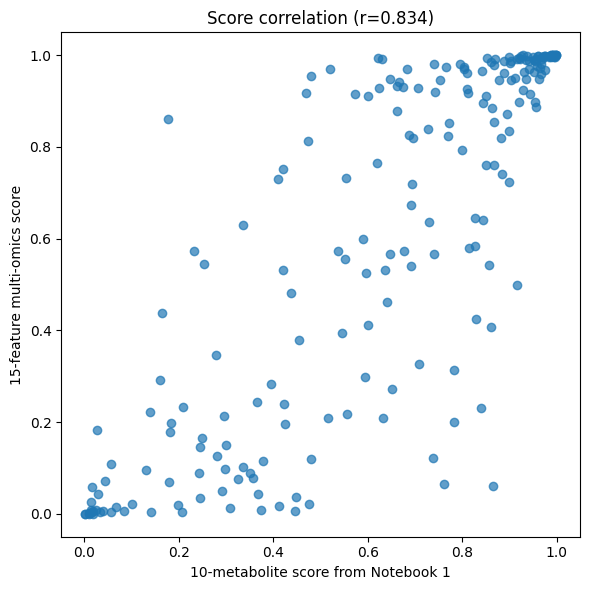

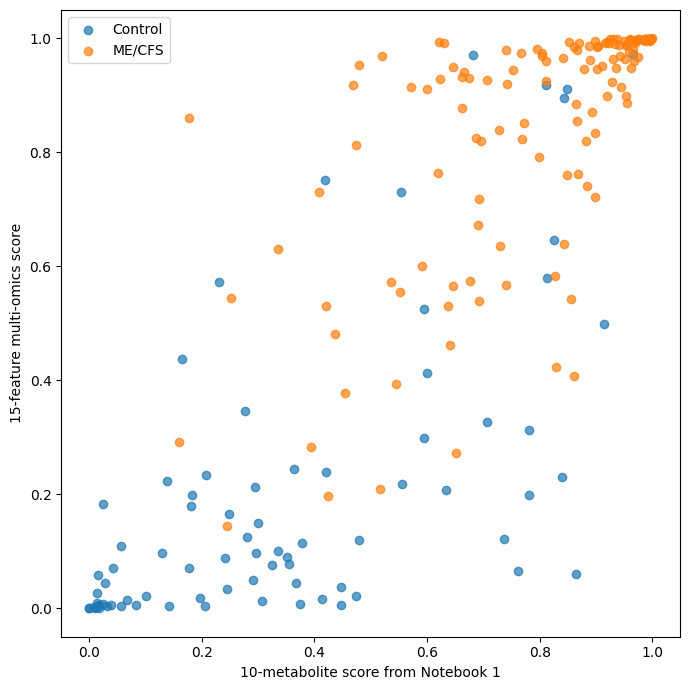

In [40]:
# =========================
# 19. Score correlation plots
# =========================

plt.figure(figsize=(6, 6))
plt.scatter(combined_scores["mecfs_score"], combined_scores["multiomics_score"], alpha=0.7)
plt.xlabel("10-metabolite score from Notebook 1")
plt.ylabel("15-feature multi-omics score")
plt.title(f"Score correlation (r={score_corr:.3f})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
for label, name in [(0, "Control"), (1, "ME/CFS")]:
    tmp = combined_scores[combined_scores["label"] == label]
    plt.scatter(tmp["mecfs_score"], tmp["multiomics_score"], alpha=0.7, label=name)

plt.xlabel("10-metabolite score from Notebook 1")
plt.ylabel("15-feature multi-omics score")
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
# =========================
# 20. Repeated train/test robustness checks
# =========================

N_SPLITS = 500
results = []

for model_name, X_data, y_data, panel in [
    ("10_metabolite_predictors_only", X_panel, y, LOCKED_PANEL),
    ("15_multiomics", X_multi, y_multi, MULTIOMICS_PANEL)
]:
    aucs = []

    for seed in range(N_SPLITS):
        X_train, X_test, y_train, y_test = train_test_split(
            X_data[panel],
            y_data,
            test_size=0.20,
            stratify=y_data,
            random_state=seed
        )

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
                random_state=seed
            ))
        ])

        pipe.fit(X_train, y_train)
        probs = pipe.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, probs))

    aucs = np.array(aucs)

    results.append({
        "model": model_name,
        "mean_auc": aucs.mean(),
        "median_auc": np.median(aucs),
        "std_auc": aucs.std(),
        "min_auc": aucs.min(),
        "max_auc": aucs.max(),
        "q05": np.quantile(aucs, 0.05),
        "q25": np.quantile(aucs, 0.25),
        "q75": np.quantile(aucs, 0.75),
        "q95": np.quantile(aucs, 0.95)
    })

    print(f"\n===== {model_name} =====")
    print(f"Mean AUC   : {aucs.mean():.3f}")
    print(f"Median AUC : {np.median(aucs):.3f}")
    print(f"Std AUC    : {aucs.std():.3f}")
    print(f"5th pct    : {np.quantile(aucs, 0.05):.3f}")
    print(f"95th pct   : {np.quantile(aucs, 0.95):.3f}")

robustness_summary = pd.DataFrame(results)
display(robustness_summary)



===== 10_metabolite_predictors_only =====
Mean AUC   : 0.859
Median AUC : 0.861
Std AUC    : 0.056
5th pct    : 0.757
95th pct   : 0.942

===== 15_multiomics =====
Mean AUC   : 0.909
Median AUC : 0.910
Std AUC    : 0.037
5th pct    : 0.844
95th pct   : 0.966


,model,mean_auc,median_auc,std_auc,min_auc,max_auc,q05,q25,q75,q95
0,10_metabolite_predictors_only,0.859014,0.861111,0.055981,0.666667,0.981481,0.756944,0.823495,0.900463,0.942130
1,15_multiomics,0.908947,0.910441,0.037317,0.792869,0.988115,0.843676,0.886036,0.937182,0.966044


Real AUC: 0.82
Null mean AUC: 0.5034
Null std AUC: 0.1387
Permutation p-value: 0.003996003996003996


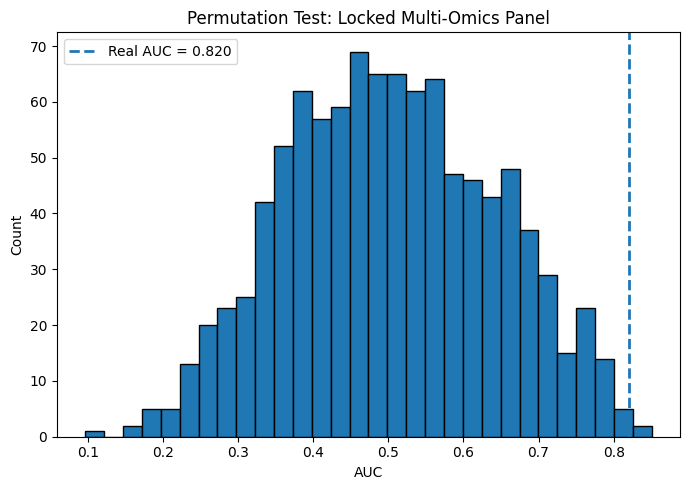

In [52]:
# =========================
# 21. Permutation test: locked multi-omics panel
# =========================

N_PERMUTATIONS = 1000

X_train, X_test, y_train, y_test = train_test_split(
    X_multi[MULTIOMICS_PANEL],
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=RANDOM_STATE
)

real_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

real_model.fit(X_train, y_train)
real_auc = roc_auc_score(y_test, real_model.predict_proba(X_test)[:, 1])

perm_aucs = []
rng = np.random.default_rng(RANDOM_STATE)

for i in range(N_PERMUTATIONS):
    y_perm = rng.permutation(y_train)

    perm_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000
        ))
    ])

    perm_model.fit(X_train, y_perm)
    perm_probs = perm_model.predict_proba(X_test)[:, 1]
    perm_aucs.append(roc_auc_score(y_test, perm_probs))

perm_aucs = np.array(perm_aucs)
p_value = (np.sum(perm_aucs >= real_auc) + 1) / (N_PERMUTATIONS + 1)

print("Real AUC:", round(real_auc, 4))
print("Null mean AUC:", round(perm_aucs.mean(), 4))
print("Null std AUC:", round(perm_aucs.std(), 4))
print("Permutation p-value:", p_value)

plt.figure(figsize=(7, 5))
plt.hist(perm_aucs, bins=30, edgecolor="black")
plt.axvline(real_auc, linestyle="--", linewidth=2, label=f"Real AUC = {real_auc:.3f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title("Permutation Test: Locked Multi-Omics Panel")
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
# ==========================================
# NB2 FINAL EXPORT
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent / "MECFS_FINAL_SIGNATURES"
NB2_DIR = ROOT / "NB3_MULTIOMICS_INTERPRETATION"

NB2_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------
# Locked panel
# ------------------------------------------

pd.DataFrame({
    "feature": MULTIOMICS_PANEL
}).to_csv(
    NB2_DIR / "01_locked_15_multiomics_panel.csv",
    index=False
)

# ------------------------------------------
# Coefficients
# ------------------------------------------

multi_coef.rename("coefficient").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    NB2_DIR / "02_15_multiomics_coefficients.csv",
    index=False
)

# ------------------------------------------
# Intercept
# ------------------------------------------

pd.DataFrame({
    "intercept": [
        final_multi_model.named_steps["logreg"].intercept_[0]
    ]
}).to_csv(
    NB2_DIR / "03_15_multiomics_intercept.csv",
    index=False
)

# ------------------------------------------
# Subject scores
# ------------------------------------------

combined_scores.to_csv(
    NB2_DIR / "04_subject_scores.csv",
    index=False
)

# ------------------------------------------
# Feature stability
# ------------------------------------------

multi_stability.to_csv(
    NB2_DIR / "05_multiomics_feature_stability.csv",
    index=False
)

# ------------------------------------------
# Panel size optimization
# ------------------------------------------

panel_results_df.to_csv(
    NB2_DIR / "06_multiomics_panel_size_cv.csv",
    index=False
)

# ------------------------------------------
# Robustness
# ------------------------------------------

robustness_summary.to_csv(
    NB2_DIR / "07_multiomics_robustness.csv",
    index=False
)

# ------------------------------------------
# Permutation test
# ------------------------------------------

pd.DataFrame([{
    "real_auc": real_auc,
    "null_mean_auc": np.mean(perm_aucs),
    "null_std_auc": np.std(perm_aucs),
    "permutation_p": p_value
}]).to_csv(
    NB2_DIR / "08_multiomics_permutation_test.csv",
    index=False
)

# ------------------------------------------
# Score correlation
# ------------------------------------------

pd.DataFrame([{
    "score_correlation": score_corr
}]).to_csv(
    NB2_DIR / "09_score_correlation.csv",
    index=False
)

print("Saved:")
print(NB2_DIR)

Saved:
c:\Users\rohan\OneDrive\Desktop\ME-CFS\src\MECFS_FINAL_SIGNATURES\NB3_MULTIOMICS_INTERPRETATION


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

PANEL = MULTIOMICS_PANEL   # or LOCKED_PANEL for 10-metabolite

X_model = X_multi[PANEL]
y_model = y_multi

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    stratify=y_model,
    random_state=42
)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

probs = pipe.predict_proba(X_test)[:, list(pipe.classes_).index(1)]

print("classes:", pipe.classes_)
print("test n:", len(y_test))
print("AUC:", roc_auc_score(y_test, probs))

classes: [0 1]
test n: 50
AUC: 0.8200339558573854


In [45]:
from sklearn.metrics import roc_auc_score
import numpy as np

def bootstrap_auc_ci(y_true, probs, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.array(y_true)
    probs = np.array(probs)

    aucs = []

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)

        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(
            roc_auc_score(y_true[idx], probs[idx])
        )

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return np.mean(aucs), lower, upper

auc_mean, auc_low, auc_high = bootstrap_auc_ci(y_test, probs)

print(f"AUC: {roc_auc_score(y_test, probs):.3f}")
print(f"Bootstrap mean: {auc_mean:.3f}")
print(f"95% CI: [{auc_low:.3f}, {auc_high:.3f}]")

AUC: 0.820
Bootstrap mean: 0.819
95% CI: [0.693, 0.920]


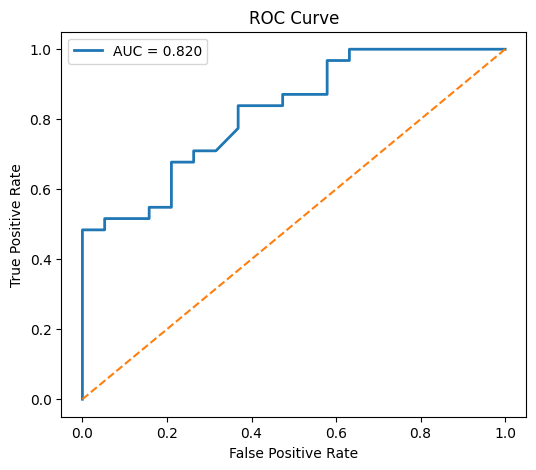

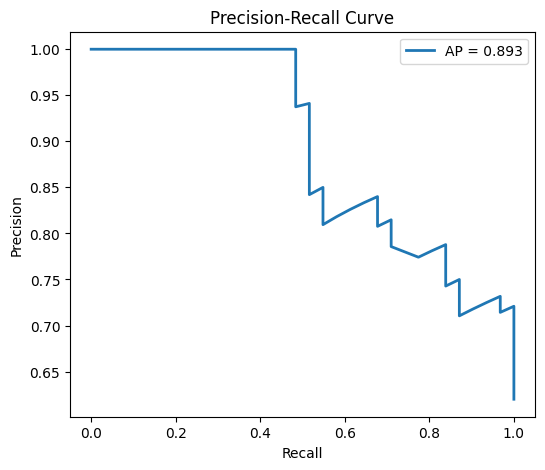

In [46]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ROC

fpr, tpr, roc_thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    probs
)

ap = average_precision_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2,
         label=f"AP = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [47]:
from sklearn.metrics import confusion_matrix

# Youden's J

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

optimal_threshold = roc_thresholds[best_idx]

y_pred = (probs >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

ppv = tp / (tp + fp)
npv = tn / (tn + fn)

accuracy = (tp + tn) / (tp + tn + fp + fn)

balanced_accuracy = (
    sensitivity + specificity
) / 2

print(f"Optimal threshold: {optimal_threshold:.3f}")
print()

print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV: {ppv:.3f}")
print(f"NPV: {npv:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced accuracy: {balanced_accuracy:.3f}")
print()

print("Confusion matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Optimal threshold: 0.933

Sensitivity: 0.484
Specificity: 1.000
PPV: 1.000
NPV: 0.543
Accuracy: 0.680
Balanced accuracy: 0.742

Confusion matrix:
TN=19, FP=0, FN=16, TP=15


In [48]:
import numpy as np
import pandas as pd

test_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

print("Controls:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].describe())

print("\nME/CFS:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].describe())

print("\nHighest control probability:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].max())

print("\nLowest ME/CFS probability:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].min())

print("\nOptimal threshold used:")
print(optimal_threshold)

Controls:
count    19.000000
mean      0.434450
std       0.354865
min       0.003273
25%       0.079170
50%       0.524450
75%       0.741283
max       0.917803
Name: prob_ME_CFS, dtype: float64

ME/CFS:
count    31.000000
mean      0.794238
std       0.258208
min       0.144674
25%       0.658547
50%       0.915694
75%       0.994426
max       0.999986
Name: prob_ME_CFS, dtype: float64

Highest control probability:
0.9178026578098297

Lowest ME/CFS probability:
0.14467412423225656

Optimal threshold used:
0.9329674944507111


In [33]:
import numpy as np
import pandas as pd

score_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

thresholds = np.arange(0.1, 1.0, 0.05)

rows = []

for low_cut in thresholds:
    for high_cut in thresholds:
        if low_cut >= high_cut:
            continue

        called_low = score_df["prob_ME_CFS"] < low_cut
        called_high = score_df["prob_ME_CFS"] > high_cut
        inconclusive = ~(called_low | called_high)

        low_group = score_df[called_low]
        high_group = score_df[called_high]

        low_correct = (low_group["y_true"] == 0).mean() if len(low_group) > 0 else np.nan
        high_correct = (high_group["y_true"] == 1).mean() if len(high_group) > 0 else np.nan

        rows.append({
            "low_cut": low_cut,
            "high_cut": high_cut,
            "n_low_called": len(low_group),
            "n_high_called": len(high_group),
            "n_inconclusive": inconclusive.sum(),
            "low_correct_rate": low_correct,
            "high_correct_rate": high_correct,
            "coverage": 1 - inconclusive.mean()
        })

range_df = pd.DataFrame(rows)

range_df.sort_values(
    ["high_correct_rate", "low_correct_rate", "coverage"],
    ascending=False
).head(20)

,low_cut,high_cut,n_low_called,n_high_called,n_inconclusive,low_correct_rate,high_correct_rate,coverage
72,0.30,0.85,9,21,20,1.000000,1.0,0.60
45,0.20,0.85,8,21,21,1.000000,1.0,0.58
59,0.25,0.85,8,21,21,1.000000,1.0,0.58
73,0.30,0.90,9,19,22,1.000000,1.0,0.56
30,0.15,0.85,6,21,23,1.000000,1.0,0.54
46,0.20,0.90,8,19,23,1.000000,1.0,0.54
60,0.25,0.90,8,19,23,1.000000,1.0,0.54
14,0.10,0.85,5,21,24,1.000000,1.0,0.52
31,0.15,0.90,6,19,25,1.000000,1.0,0.50
74,0.30,0.95,9,16,25,1.000000,1.0,0.50


In [49]:
# =========================
# All-feature multiomics vs locked 15-feature panel
# Held-out AUC + score correlation
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -------------------------
# Helper function
# -------------------------

def fit_eval_and_oof_scores(X_data, y_data, model_name, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.20,
        stratify=y_data,
        random_state=random_state
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=random_state
        ))
    ])

    model.fit(X_train, y_train)

    test_probs = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
    heldout_auc = roc_auc_score(y_test, test_probs)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    oof_probs = cross_val_predict(
        model,
        X_data,
        y_data,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    score_df = pd.DataFrame({
        "participant_id": X_data.index.astype(str),
        "label": y_data.values,
        f"{model_name}_score": oof_probs
    })

    return heldout_auc, score_df


# -------------------------
# 1. All-feature multiomics
# -------------------------

X_all = X_multi.copy()
y_all = y_multi.copy()

auc_all, all_score_df = fit_eval_and_oof_scores(
    X_all,
    y_all,
    model_name="all_feature"
)

print("All-feature multiomics shape:", X_all.shape)
print("All-feature held-out AUC:", auc_all)


# -------------------------
# 2. Locked 15-feature multiomics panel
# -------------------------

X_15 = X_multi[MULTIOMICS_PANEL].copy()
y_15 = y_multi.copy()

auc_15, score15_df = fit_eval_and_oof_scores(
    X_15,
    y_15,
    model_name="panel15"
)

print("\n15-feature panel shape:", X_15.shape)
print("15-feature held-out AUC:", auc_15)


# -------------------------
# 3. Merge scores and correlate
# -------------------------

combined_scores = (
    score15_df
    .merge(
        all_score_df[["participant_id", "all_feature_score"]],
        on="participant_id",
        how="inner"
    )
)

score_corr = combined_scores["panel15_score"].corr(
    combined_scores["all_feature_score"]
)

print("\nMerged shape:", combined_scores.shape)
print("15-panel vs all-feature score correlation:", score_corr)

display(combined_scores.head())

All-feature multiomics shape: (249, 5774)
All-feature held-out AUC: 0.66723259762309

15-feature panel shape: (249, 15)
15-feature held-out AUC: 0.8200339558573854

Merged shape: (249, 4)
15-panel vs all-feature score correlation: 0.4757211206874544


,participant_id,label,panel15_score,all_feature_score
0,SAM000269,1,0.614891,0.036922
1,SAM000268,1,0.415562,1.000000
2,SAM000266,1,0.174845,0.000183
3,SAM000257,0,0.021727,0.000001
4,SAM000260,1,0.688006,0.160241


In [50]:
# =========================
# 15-panel vs all-features
# repeated holdout validation
# =========================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

N_SPLITS = 500

auc_15 = []
auc_all = []

for seed in range(N_SPLITS):

    # ---------------------
    # 15-feature panel
    # ---------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X_multi[MULTIOMICS_PANEL],
        y_multi,
        test_size=0.20,
        stratify=y_multi,
        random_state=seed
    )

    model15 = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    model15.fit(X_train, y_train)

    probs15 = model15.predict_proba(X_test)[:,1]

    auc_15.append(
        roc_auc_score(y_test, probs15)
    )

    # ---------------------
    # all features
    # ---------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X_multi,
        y_multi,
        test_size=0.20,
        stratify=y_multi,
        random_state=seed
    )

    model_all = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    model_all.fit(X_train, y_train)

    probs_all = model_all.predict_proba(X_test)[:,1]

    auc_all.append(
        roc_auc_score(y_test, probs_all)
    )

# ---------------------
# Results
# ---------------------

print("15-feature panel")
print("Mean AUC:", np.mean(auc_15))
print("Std AUC :", np.std(auc_15))

print()

print("All features")
print("Mean AUC:", np.mean(auc_all))
print("Std AUC :", np.std(auc_all))

print()

wins = np.mean(np.array(auc_15) > np.array(auc_all))
print("Fraction of splits where 15-panel wins:", wins)

KeyboardInterrupt: 